In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.DataFrame({
    "study_hours": [1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,2,3,5,6,7,4,5,6,8,9],

    "attendance_rate": [60,65,70,72,75,78,80,82,84,85,87,88,90,92,95,68,74,83,86,91,79,81,88,94,96],

    "sleep_hours": [5,6,5,6,7,6,7,7,8,6,7,8,7,8,7,5,6,7,6,8,7,6,7,8,7],

    "assignment_score": [40,50,55,58,60,65,68,72,74,78,80,84,86,90,92,52,59,73,79,88,66,71,82,91,95],
    "youtube_hours": [5,4,5,4,3,3,2,2,2,2,1,1,1,1,1,4,3,2,2,1,3,2,1,1,1],

    "game_hours": [4,3,4,3,3,2,2,2,1,1,1,1,1,0,0,4,3,2,1,1,2,2,1,0,0],

    "exercise_hours": [0,0,1,1,1,1,2,2,2,2,2,3,3,3,3,1,1,2,2,3,2,2,2,3,3],
    "final_score": [45,50,53,58,61,66,69,73,76,80,83,87,89,93,95,54,60,75,81,90,68,74,84,94,98]
})

print(df)

    study_hours  attendance_rate  sleep_hours  assignment_score  \
0             1               60            5                40   
1             2               65            6                50   
2             2               70            5                55   
3             3               72            6                58   
4             3               75            7                60   
5             4               78            6                65   
6             4               80            7                68   
7             5               82            7                72   
8             5               84            8                74   
9             6               85            6                78   
10            6               87            7                80   
11            7               88            8                84   
12            7               90            7                86   
13            8               92            8                9

In [2]:
# 기초통계분석 / 전처리
print(df.describe())

       study_hours  attendance_rate  sleep_hours  assignment_score  \
count    25.000000        25.000000    25.000000         25.000000   
mean      5.040000        81.720000     6.680000         72.320000   
std       2.207563         9.650216     0.945163         14.817557   
min       1.000000        60.000000     5.000000         40.000000   
25%       3.000000        75.000000     6.000000         60.000000   
50%       5.000000        83.000000     7.000000         73.000000   
75%       7.000000        88.000000     7.000000         84.000000   
max       9.000000        96.000000     8.000000         95.000000   

       youtube_hours  game_hours  exercise_hours  final_score  
count       25.00000   25.000000       25.000000    25.000000  
mean         2.28000    1.760000        1.880000    74.240000  
std          1.30767    1.267544        0.927362    15.414495  
min          1.00000    0.000000        0.000000    45.000000  
25%          1.00000    1.000000        1.000000 

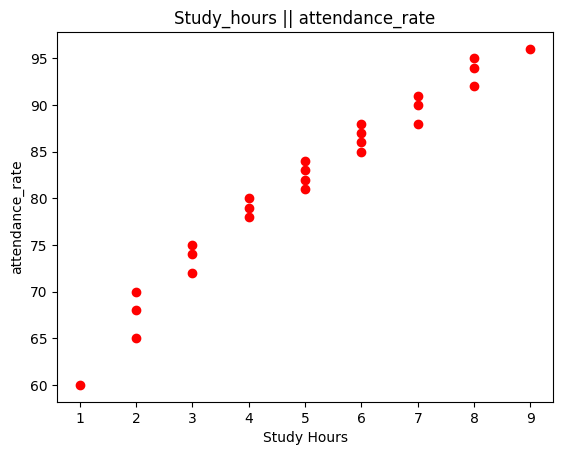

In [3]:
# 시각화 하기 실제값먼저 ( 하루 평균 공부시간을 중점으로 먼저 출석률)
#산점도 그래프
plt.scatter(df['study_hours'], df['attendance_rate'], color='red')
plt.title('Study_hours || attendance_rate')
plt.xlabel('Study Hours')
plt.ylabel('attendance_rate')
plt.show()

# 공부를 많이 하는 사람일수록 출석률은 높음

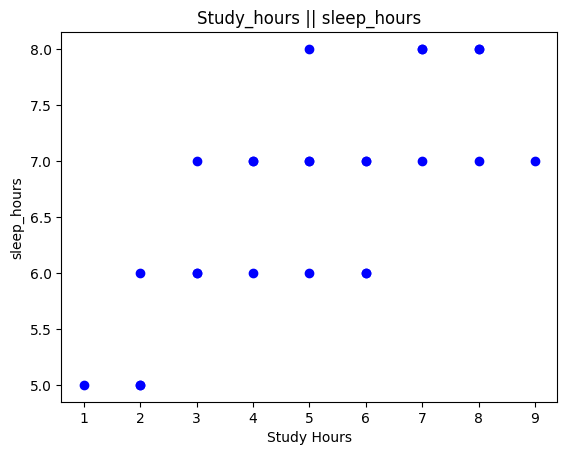

In [4]:
# 다음은 공부시간과  평균 수면 시간
#산점도 그래프
plt.scatter(df['study_hours'], df['sleep_hours'], color='blue')
plt.title('Study_hours || sleep_hours')
plt.xlabel('Study Hours')
plt.ylabel('sleep_hours')
plt.show()
# 공부 시간이 많지 않은 학생은 잠을 많이 자진 않는다 하지만 그렇다고 
# 공부를 많이 하는 학생들 역시 잠을 가장 오래 자지 않고 평균인 학생들이 많이 잔다

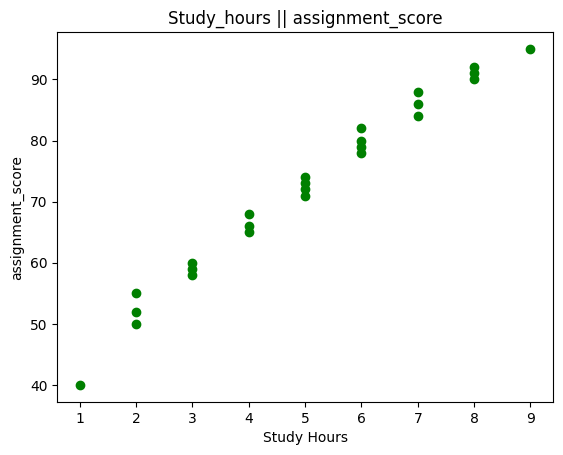

In [5]:
# 다음은 공부시간과 과제 평균 점수 비교
#산점도 그래프
plt.scatter(df['study_hours'], df['assignment_score'], color='green')
plt.title('Study_hours || assignment_score')
plt.xlabel('Study Hours')
plt.ylabel('assignment_score')
plt.show()

# 이 역시 공부를 적게 한 학생들 평균은 젤 낮고 공부량이 많을수록 올라감

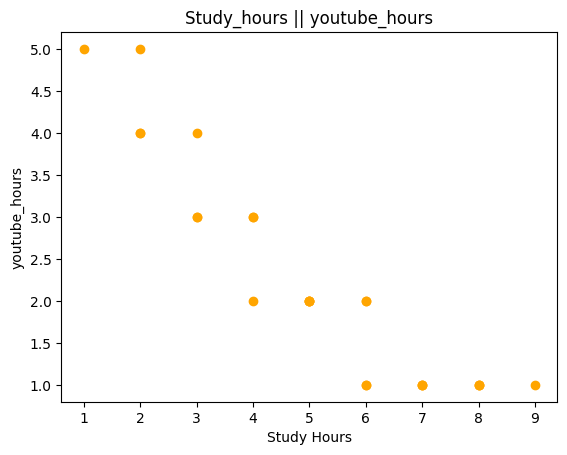

In [6]:
# 다음은 공부시간과 하루 유튜브 시청시간 비교
#산점도 그래프
plt.scatter(df['study_hours'], df['youtube_hours'], color='orange')
plt.title('Study_hours || youtube_hours')
plt.xlabel('Study Hours')
plt.ylabel('youtube_hours')
plt.show()
# 다른 형상과 반대로 공부량이 젤 적은 학생일수록 유튜브 시청 시간이 많고 
# 공부시간이 많은 학생일수록 유튜브 시청 시간이 적다

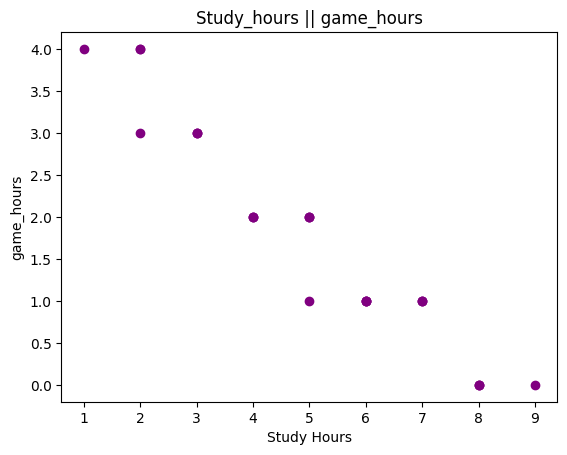

In [7]:
# 다음은 공부시간과 게임 시간 비교하기
#산점도 그래프
plt.scatter(df['study_hours'], df['game_hours'], color='purple')
plt.title('Study_hours || game_hours')
plt.xlabel('Study Hours')
plt.ylabel('game_hours')
plt.show()

# 게임 시간 역시 유튜브 시청과 산점도 그래프가 비슷함

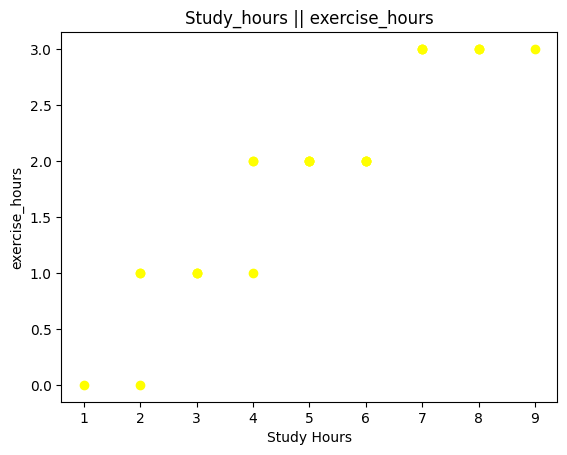

In [8]:
# 다음은 공부시간과 운동시간 비교
#산점도 그래프
plt.scatter(df['study_hours'], df['exercise_hours'], color='yellow')
plt.title('Study_hours || exercise_hours')
plt.xlabel('Study Hours')
plt.ylabel('exercise_hours')
plt.show()

# 기대와 달리 공부량이 많은 아이들이 운동도 더 한다는 것을 알 수 있음

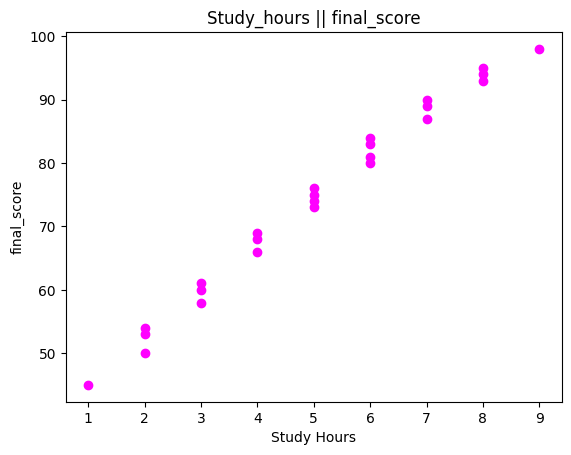

In [9]:
# 다음은 공부시간과 최종시험 점수 비교
#산점도 그래프
plt.scatter(df['study_hours'], df['final_score'], color='magenta')
plt.title('Study_hours || final_score')
plt.xlabel('Study Hours')
plt.ylabel('final_score')
plt.show()

# 예상했듯이 공부량이 많은 아이들이 더 높은 성적을 받게 됨


In [10]:
# 결론적으로 볼때  평균 수면 시간을 제외, 하루 유튜브 시청, 게임을 제외하고는 비레함

In [11]:
# 데이터셋 나누기

# 학습 성과에 영향을 주는 요인을 분석하기 위해
# 공부시간(study_hours), 출석률(attendance_rate), 운동시간(exercise_hours)을 독립변수로 설정, 최종 성적(final_score)을 종속변수로 설정
# 단순 공부량뿐 아니라 생활 패턴이 성적에 미치는 영향도 함께 분석

X = df[['study_hours', 'attendance_rate', 'exercise_hours']]

y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2, # 테스트용으로 데이터 자르라는 뜻
    random_state = 42 # 데이터를 랜덤하게 섞어 실행할 때마다 같은 결과가 나오게 설정
)

In [12]:
# 모델 학습, 이번엔 선형이 아닌 다중 선형으로 응용하여 해결해보기
model = LinearRegression() # y = ax1 + bx2 + cx3 + d
model.fit(X_train, y_train)

print("계수(기울기)", model.coef_)
print("절편 intercept", model.intercept_)
# 절편이 음수가 나온다고 틀린건 아님 -> 공부시간, 출석률, 운동시간이 모두 0인 비현실적인 상황을 기준으로 계산된 값 
# 공부시간이 1시간 늘면 3.24점 상승을 하고 춣석률은 0.81, 운동시간은 0.82 상승으로 긍정적임

계수(기울기) [3.24626206 0.81146782 0.82065415]
절편 intercept -10.077261104141527


In [ ]:
# 평가
y_pred = model.predict(X_test)
print(y_pred)
print(y_test)

mse = mean_squared_error(y_test, y_pred)
print('mse : ',mse)

r2 = r2_score(y_test, y_pred)
print('R^2 : ', r2)

#RMSE 평가
rmse = np.sqrt(mse)
print('rmse: ', rmse) # 실제 점수랑 차이

# 


[75.95865468 60.53079818 41.85707039 94.63277324 86.51770424]
8     76
16    60
0     45
23    94
11    87
Name: final_score, dtype: int64
mse :  2.1588947767408393
R^2 :  0.9932416266693562
rmse:  1.4693177929708874


In [ ]:
# 새로운 값 예측
# 새로운 학생 데이터 예측
# 공부시간은 충분히 확보하고, 출석률 또한 우수한 학생을 가정
# 여기에 운동시간이 성적에 어떤 영향을 주는지 확인
new_X = [[8, 95, 2], # 공부시간 8시간, 출석률 : 95, 운동시간 2
         [7, 93, 1]] # 공부시간 7시간, 출석률 : 93, 운동시간 1 

new_y = model.predict(new_X)
print(new_y)

[94.62358692 88.93373506]


c:\Users\human-03\Desktop\AI\Linear\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
